In [1]:
import pandas as pd

japan_english_filepath = "../../project/data/raw/japan_english_news_kaggle.csv"
JPnews_pd = pd.read_csv(japan_english_filepath, sep='\t') 

JPnews_pd.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36889 entries, 0 to 36888
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   source  36889 non-null  object
 1   date    36889 non-null  object
 2   title   36889 non-null  object
 3   author  12846 non-null  object
 4   text    36766 non-null  object
dtypes: object(5)
memory usage: 1.4+ MB


source
The Japan Times     36815
Mainichi Shimbun       74
Name: count, dtype: int64

Total sources: 2


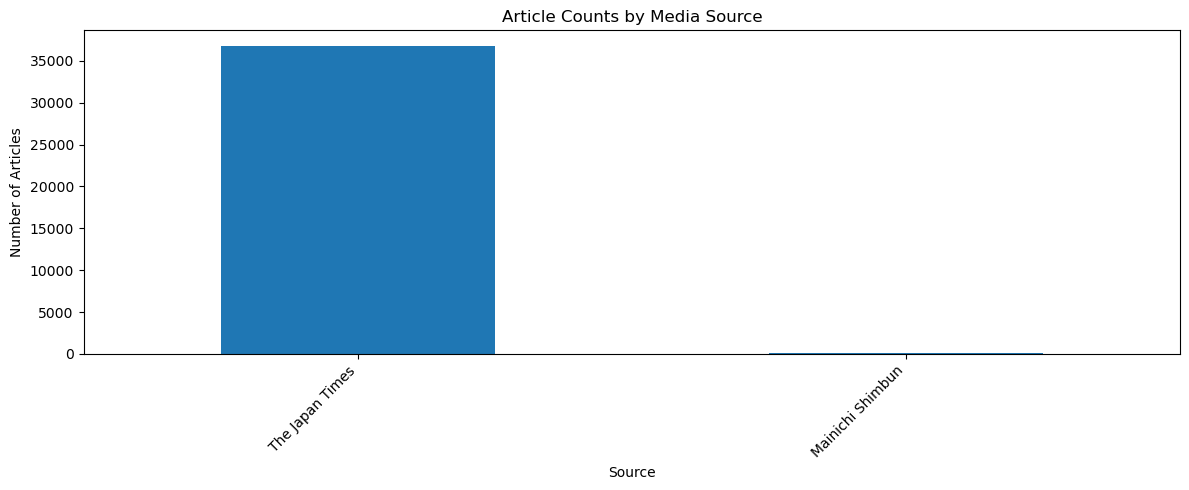

In [2]:
import matplotlib.pyplot as plt

source_count = JPnews_pd['source'].value_counts()
print(source_count)
print(f"\nTotal sources: {JPnews_pd['source'].nunique()}")

source_count.plot(kind='bar', figsize=(12, 5))
plt.title('Article Counts by Media Source')
plt.xlabel('Source')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

       text_char_len  text_word_len
count   36766.000000   36766.000000
mean      797.178997     128.168172
std       310.121481      51.434808
min       133.000000      24.000000
25%       667.000000     106.000000
50%       736.000000     118.000000
75%       835.000000     134.000000
max     15605.000000    2577.000000


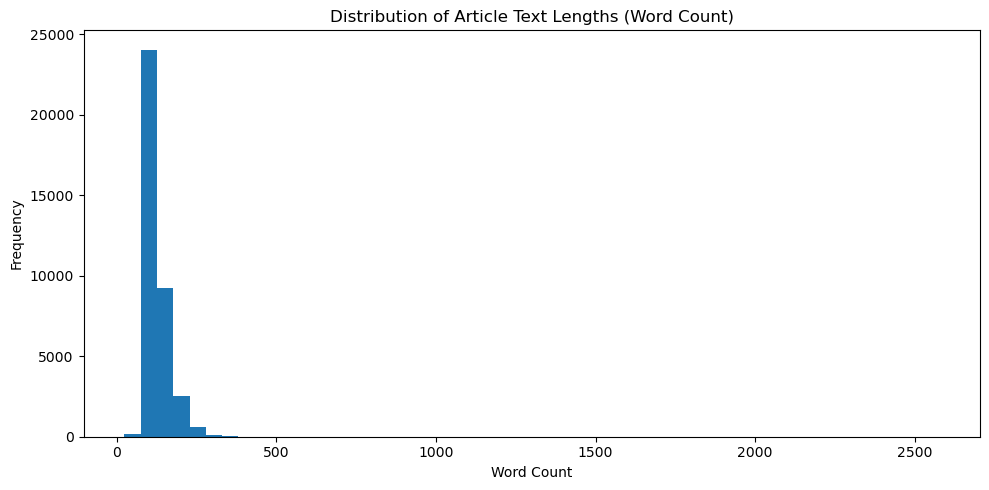

In [3]:
JPnews_pd['text_char_len'] = JPnews_pd['text'].dropna().apply(len)
JPnews_pd['text_word_len'] = JPnews_pd['text'].dropna().apply(lambda x: len(str(x).split()))

print(JPnews_pd[['text_char_len', 'text_word_len']].describe())

JPnews_pd['text_word_len'].plot(kind='hist', bins=50, figsize=(10, 5))
plt.title('Distribution of Article Text Lengths (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [4]:
JPnews_pd['date'] = pd.to_datetime(JPnews_pd['date'])

monthly_count = JPnews_pd['date'].groupby(JPnews_pd['date'].dt.to_period('M')).size()
print(monthly_count)


date
2001-01     977
2001-02    1155
2001-03    1043
2001-04    1097
2001-05    1155
           ... 
2021-08       6
2021-09       6
2021-10       9
2021-11       1
2021-12      37
Freq: M, Name: date, Length: 68, dtype: int64


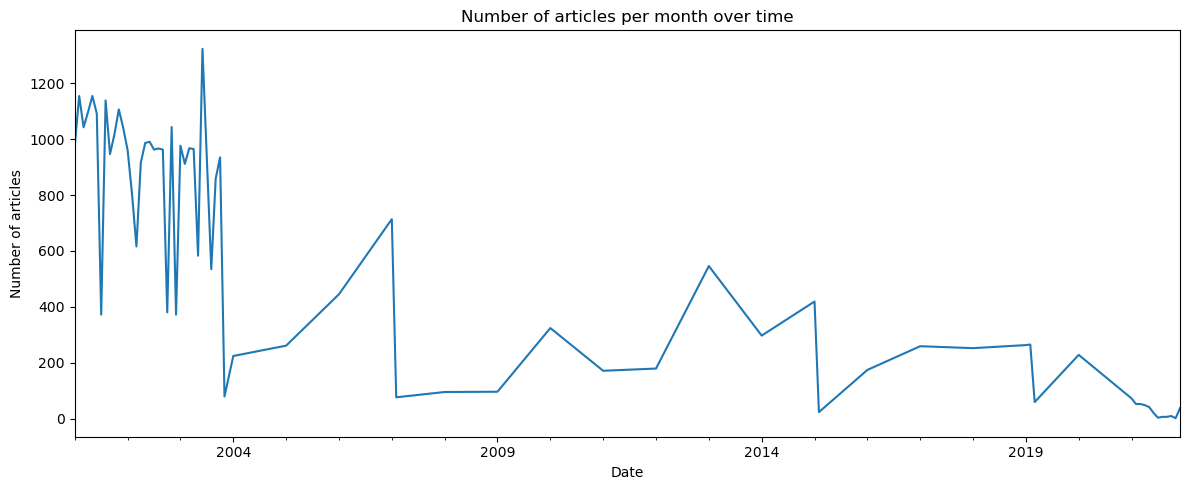

In [5]:
monthly_count.plot(kind='line', figsize=(12,5))
plt.title ('Number of articles per month over time')
plt.xlabel ('Date')
plt.ylabel ('Number of articles')
plt.tight_layout()


In [6]:
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer

clean_text = JPnews_pd['text'].dropna()

vectorizer = CountVectorizer(token_pattern=r"(?u)\b[a-zA-Z]{6,}\b")
count_array = vectorizer.fit_transform(clean_text).toarray()

df_wordcount = pd.DataFrame(
    count_array, # Data above will become the values of the dataframe
    columns=vectorizer.get_feature_names_out(), # Words will become the column names
    index = clean_text.index # Index country date comes from the df_all dataframe
)
df_wordcount.head(2)

,aachen,aadhaar,aahing,aardvarks,abacus,abadia,abakaexplosion,abalone,abandon,abandoned,...,zushishop,zuzana,zvezda,zvonareva,zwigoff,zwijnenberg,zwolle,zydeco,zygotic,zymurgy
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df_wordcount.sum(axis='rows').sort_values(ascending=False).to_frame("most_common").head(10)

,most_common
please,73498
security,37867
support,37843
allowed,36988
conflict,36934
software,36914
unable,36888
resolve,36871
apologize,36770
blocking,36745


<Axes: >

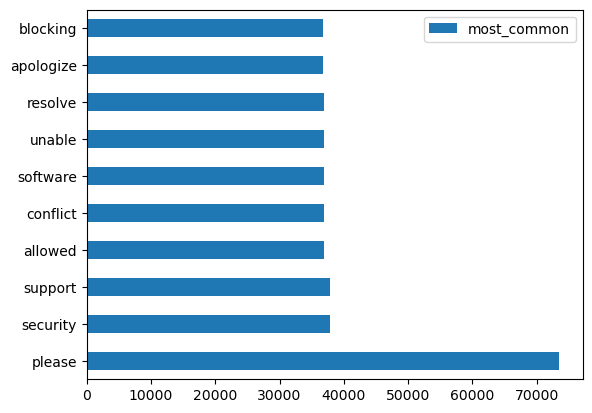

In [8]:
df_wordcount.sum(axis='rows').sort_values(ascending=False).to_frame("most_common").head(10).plot(kind = 'barh')

Note: you may need to restart the kernel to use updated packages.


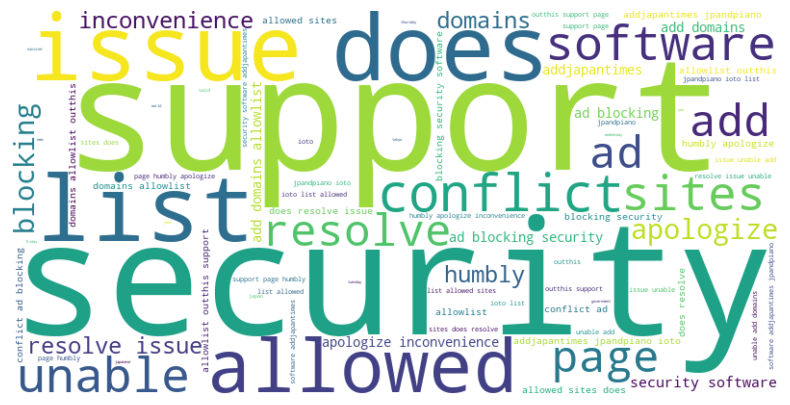

In [10]:
vectorizer = CountVectorizer(
    analyzer = 'word',          # Whether the feature should be made of word or character n-grams or a mixture of both.
    stop_words = 'english',     # Remove stop words. Can be a list of stop words or a string from {'english', 'spanish'}.
    lowercase = True,           # Convert text to lowercase.
    ngram_range = (1,3),
    min_df = .1
    
)
counts = vectorizer.fit_transform(clean_text).toarray().sum(axis=0)
word_freq = dict(zip(vectorizer.get_feature_names_out(), counts))

%pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white')
wordcloud.generate_from_frequencies(word_freq)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.savefig('wordcloud.png', bbox_inches='tight', dpi=300)
plt.show()